# Chapter 11 — Backtesting III: Walk-Forward and Statistical Validation

This is the chapter that closes the deflation arc. Ch8 produced an in-sample Sharpe of **+2.08**. Ch9 fixed the mechanics and brought it to **+0.80**. Ch10 fixed bias from look-ahead and snooping, but every Sharpe Ch10 quoted was still computed on the same data used to choose the strategy's parameters. Ch11 introduces the discipline of separating those two activities — *parameter selection* and *performance estimation*.

The job here is the simplest validation question that exists: **does the strategy survive on data the strategy has never seen?**

Three flavors of "did it work out-of-sample?":

1. **Train/test split** — the cheapest validation. Hold out the last 30% of sessions, fit on the first 70%, evaluate the trained parameter on the held-out portion. Single comparison; quick to compute; honest if you do it once.
2. **Walk-forward optimization** — refit monthly on a 3-month trailing window; concatenate the OOS PnL across all rolls. Yields a continuously-OOS PnL series and a sequence of parameter choices whose stability you can inspect.
3. **Bootstrap CI on OOS PnL** — the OOS Sharpe is itself noisy. The CI is what tells you whether the strategy is statistically distinguishable from random.

The chapter's punchline number — the one to carry into Ch12 and beyond — is the walk-forward concatenated OOS Sharpe with its bootstrap CI. The honest answer for this strategy on this data: **+0.88, 95% CI ≈ (−1.6, +3.5)**. Positive point estimate; CI comfortably includes zero.

## Three things this chapter covers

1. **The IS/OOS gap is the real signal-to-noise.** Section §1. A strategy with IS Sharpe 2.0 and OOS Sharpe 0.6 is real but weak; a strategy with IS Sharpe 2.0 and OOS Sharpe 0.0 was a curve fit. The two look identical at the IS stage; only OOS distinguishes them.
2. **Walk-forward gives you adaptive evaluation.** Section §3. Parameters refit window-by-window; you observe the *sequence* of choices as well as the OOS performance. Parameter stability is its own diagnostic.
3. **A point Sharpe without a CI is incomplete.** Section §4. Even an OOS point Sharpe is a noisy estimator. Block-bootstrapping the OOS PnL — at the trade level *and* at the daily level — gives you both the lower bound (the smallest plausible truth) and the upper bound (the strategy isn't *that* good either).

> **Definition — in-sample (IS).** Performance computed on the exact data used to choose the strategy's parameters. An *upper bound* on what the strategy can really do, never the strategy's actual edge. Always optimistic.
>
> **Definition — out-of-sample (OOS).** Performance computed on data the strategy has never seen — neither during parameter selection nor during any "this looks reasonable" decision. Slightly less optimistic than IS by construction; tracking truth more closely.
>
> **Definition — train/test split.** A single partition of the dataset into a `train` portion (used for parameter selection) and a `test` portion (held out for OOS evaluation). The simplest validation; honest if you only evaluate on the test set *once*.
>
> **Definition — walk-forward optimization.** Repeated train/test splits in chronological sliding-window form. At each step, refit on a trailing window, evaluate on the next window, slide forward. Concatenate OOS evaluations into a single series.
>
> **Definition — deflation factor.** The ratio OOS Sharpe / IS Sharpe. A typical retail strategy deflates to 0.3-0.7. Above 0.7 is suspicious (suggests not enough genuine OOS, or accidental information leakage). At 0 means the IS was noise.

## §1 — The IS/OOS gap is the real signal-to-noise ratio

Every IS Sharpe is, mechanically, an *upper bound* on the strategy's true expected performance. The mechanism is parameter selection: you sweep, you pick the best. The "best" is the maximum over noisy estimates and exceeds any single estimate's mean by construction.

The OOS Sharpe is the lower-variance estimator of truth. Truth itself — what the strategy will actually produce on data not yet observed — sits between IS and OOS in expectation, closer to OOS than to IS.

Two numerical examples to anchor intuition. Both refer to a hypothetical strategy with a "true" Sharpe of 0.5:

- IS = 2.0, OOS = 0.6. Plausible; the IS picks up genuine signal plus some snooping inflation; OOS captures the signal without the inflation. **Real-but-weak**.
- IS = 2.0, OOS = 0.0. Also plausible; the IS was almost entirely noise plus snooping; OOS realized truth = 0. **Curve fit**.

The difference is the deflation factor (OOS / IS):

- 0.30 in the first case (real-but-weak)
- 0.00 in the second (curve fit)

Without OOS, you literally cannot distinguish these two strategies. *Every* serious quant pipeline runs OOS validation; *no* serious quant pipeline reports IS Sharpe as the strategy's edge.

## §2 — Train/test split

The simplest possible validation. We hold out the last 30% of sessions as the test window — 76 sessions, roughly 4 months. We sweep `k_σ` across 21 values on the first 70% (175 sessions), pick the in-sample best, and apply it *unchanged* to the held-out portion.

> **Definition — holdout set.** Synonymous with the test set in a train/test split. The portion of the data the strategy and its parameters are *never* fit to.
>
> **Operational rule:** evaluate on the holdout exactly once. Iterate on the holdout — re-tune after seeing OOS performance — and you have effectively re-merged train and test, with all the snooping that implies.

### Results

| Quantity                          | Value   |
| --------------------------------- | ------- |
| Best train k_σ                    | 1.40    |
| IS Sharpe (train, 175 sessions)   | **+1.65** |
| OOS Sharpe (test, 76 sessions)    | **+0.46** |
| Deflation factor (OOS / IS)       | 0.28    |

**The held-out 30% retained roughly one-quarter of the in-sample Sharpe.** That deflation factor of 0.28 sits at the severe end of the typical 0.3-0.7 range — the strategy was meaningfully fit to the train portion. The OOS Sharpe of +0.46 is below the 0.5 retail-tradable threshold, but only just.

### A subtle finding

Ch10 §4's *full-sample* sweep best was `k_σ = 0.50` with Sharpe +1.86. Here, on the train portion alone, the best is `k_σ = 1.40`. **The "best" parameter is itself unstable across windows.**

That instability is informative. Snooping bias produces unstable choices, not just inflated Sharpes. If the optimizer picks `k_σ = 0.50` on the full sample but `k_σ = 1.40` on the first 70% of sessions, the parameter is not *measuring something stable about the strategy* — it is *fitting noise specific to each window*. Real edges produce stable optimizers.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CACHE = Path("../06-bridge-to-intraday/data")
qqq = pd.read_parquet(CACHE / "qqq_1min.parquet")
qqq.index = pd.to_datetime(qqq.index, utc=True).tz_convert("America/New_York")
qqq["minute_of_day"] = qqq.index.hour * 60 + qqq.index.minute
RTH_OPEN, RTH_CLOSE = 9*60+30, 16*60
rth = qqq[(qqq["minute_of_day"] >= RTH_OPEN) & (qqq["minute_of_day"] < RTH_CLOSE)].copy()
rth["minute_of_session"] = rth["minute_of_day"] - RTH_OPEN
rth["session_date"] = rth.index.normalize()
rth["log_ret"] = np.log(rth["close"] / rth["close"].shift(1))
sf = rth.groupby("session_date").head(1).index
rth.loc[sf, "log_ret"] = np.nan

N, K = 1, 3
ENTRY_START, ENTRY_END = 360, 389

priors_by_session = {}
for date, day in rth.groupby("session_date"):
    day = day.sort_index().reset_index(drop=True)
    pts = []
    for i in range(N, len(day)):
        if ENTRY_START <= day.loc[i, "minute_of_session"] < ENTRY_END - K:
            pts.append(np.log(day.loc[i, "close"] / day.loc[i - N, "close"]))
    priors_by_session[date] = np.array(pts)
sessions_all = sorted(priors_by_session.keys())
print(f"{len(sessions_all)} sessions  ·  {sessions_all[0].date()} → {sessions_all[-1].date()}")


251 sessions  ·  2025-05-08 → 2026-05-07


In [2]:
def sigma_from_sessions(sessions_iter):
    pts = [priors_by_session[s] for s in sessions_iter if s in priors_by_session]
    if not pts: return None
    arr = np.concatenate(pts)
    return arr.std() if len(arr) > 0 else None

def event_driven_backtest(rth_df, sessions_set, k_sigma, sigma):
    """Run the single-position event-driven backtest restricted to sessions_set,
    with threshold = k_sigma * sigma (sigma is from a separate point-in-time set)."""
    threshold = k_sigma * sigma
    sub = rth_df[rth_df["session_date"].isin(sessions_set)]
    trades = []
    for date, day in sub.groupby("session_date"):
        day = day.sort_index().reset_index(drop=True)
        in_pos, entry_i, entry_px = 0, None, None
        for i in range(len(day)):
            mos   = day.loc[i, "minute_of_session"]
            close = day.loc[i, "close"]
            if in_pos != 0 and (i - entry_i) >= K:
                exit_i  = min(i + 1, len(day) - 1)
                exit_px = day.loc[exit_i, "open"]
                trades.append({"date": date, "side": in_pos,
                               "pnl_log": in_pos * np.log(exit_px / entry_px)})
                in_pos, entry_i, entry_px = 0, None, None
            if in_pos == 0 and ENTRY_START <= mos < ENTRY_END - K and i >= N:
                prior_N = np.log(close / day.loc[i - N, "close"])
                if abs(prior_N) > threshold:
                    sig = -1 if prior_N > 0 else +1
                    entry_i_next = min(i + 1, len(day) - 1)
                    in_pos, entry_i, entry_px = sig, i, day.loc[entry_i_next, "open"]
        if in_pos != 0:
            close_last = day.loc[len(day) - 1, "close"]
            trades.append({"date": date, "side": in_pos,
                           "pnl_log": in_pos * np.log(close_last / entry_px)})
    return pd.DataFrame(trades)

def sharpe(tr):
    if len(tr) < 2: return float("nan")
    mu, sd = tr["pnl_log"].mean(), tr["pnl_log"].std()
    if sd == 0: return float("nan")
    s = tr["date"].nunique()
    return (mu / sd) * np.sqrt(252 * len(tr) / max(s, 1))


In [3]:
split = int(0.7 * len(sessions_all))
train_sessions = set(sessions_all[:split])
test_sessions  = set(sessions_all[split:])
train_sigma = sigma_from_sessions(train_sessions)

print(f"Train: {len(train_sessions)} sessions  σ={train_sigma:.6f}")
print(f"Test:  {len(test_sessions)} sessions")

# Sweep k_sigma on train; pick best
sweep_rows = []
for k_sigma in np.linspace(0.5, 2.5, 21):
    tr_train = event_driven_backtest(rth, train_sessions, k_sigma, train_sigma)
    tr_test  = event_driven_backtest(rth, test_sessions,  k_sigma, train_sigma)
    sweep_rows.append({
        "k_sigma": round(k_sigma, 2),
        "is_sharpe":  round(sharpe(tr_train), 3),
        "oos_sharpe": round(sharpe(tr_test),  3),
        "is_n":  len(tr_train),
        "oos_n": len(tr_test),
    })
sweep_tt = pd.DataFrame(sweep_rows)
best_idx = sweep_tt["is_sharpe"].idxmax()
best = sweep_tt.iloc[best_idx]
print(f"\nBest train k_σ: {best['k_sigma']:.2f}")
print(f"  IS Sharpe:  {best['is_sharpe']:+.3f}")
print(f"  OOS Sharpe: {best['oos_sharpe']:+.3f}")
print(f"  Deflation factor (OOS / IS): {best['oos_sharpe'] / best['is_sharpe']:.2f}")
sweep_tt


Train: 175 sessions  σ=0.000349
Test:  76 sessions



Best train k_σ: 1.40
  IS Sharpe:  +1.652
  OOS Sharpe: +0.460
  Deflation factor (OOS / IS): 0.28


,k_sigma,is_sharpe,oos_sharpe,is_n,oos_n
0,0.5,0.545,3.273,1079,526
1,0.6,0.830,2.903,969,490
2,0.7,1.148,2.338,865,454
3,0.8,1.160,3.336,784,416
4,0.9,0.697,2.263,695,382
5,1.0,0.750,1.285,610,353
6,1.1,1.290,1.275,546,317
7,1.2,1.496,-0.126,488,291
8,1.3,1.144,-0.517,436,254
9,1.4,1.652,0.460,379,235


## §3 — Walk-forward optimization

Train/test split is one comparison. Walk-forward is many — and crucially, it lets the strategy *adapt* between windows. The procedure:

1. Slide a 3-month training window along the data, advancing one month at a time.
2. At each step, refit the strategy parameter (sweep `k_σ` ∈ [0.5, 2.5] in 21 steps; pick IS best) on the trailing 3 months. Refit σ from the same 3 months.
3. Evaluate the refit strategy on the *next* month, using its own σ (point-in-time-clean).
4. Concatenate the OOS trades across all walk-forward steps; compute aggregate metrics on the combined ledger.

The output is a continuously-OOS PnL series and a sequence of parameter choices.

### What the procedure shows

10 effective walk-forward windows after the 3-month warmup. Per-window summary:

| Month   | k_σ best | IS Sharpe | OOS trades | OOS Sharpe |
| ------- | -------- | --------- | ---------- | ---------- |
| 2025-08 | 1.6      | +3.34     |  19        | −0.73      |
| 2025-09 | 1.5      | +5.22     |  42        | +2.49      |
| 2025-10 | 2.5      | +6.47     |  36        | −1.36      |
| 2025-11 | 1.2      | +1.37     | 104        | −0.59      |
| 2025-12 | 0.7      | +1.59     |  77        | +1.36      |
| 2026-01 | 0.7      | +1.35     |  92        | −0.41      |
| 2026-02 | 0.7      | +2.54     | 116        | +5.62      |
| 2026-03 | 1.8      | +4.22     |  64        | +4.53      |
| 2026-04 | 2.1      | +5.36     |   8        | −17.6      |
| 2026-05 | 0.7      | +3.05     |  17        | +2.97      |

**Walk-forward concatenated OOS Sharpe: +0.88** (575 trades over 148 sessions).

### Reading the table

Three observations.

**1. Concatenate the trade ledger; do not average per-month Sharpes.** The 10 monthly Sharpes range from −17.6 (Apr) to +5.6 (Feb); their simple mean is dominated by the two anomalously bad windows. What the strategy would have *produced* in real trading is the trade-weighted concat number (+0.88), where 116 February trades count more than 8 April trades.

The April number deserves a flag. The optimizer picked `k_σ = 2.1` on March's training window, which is restrictive; only 8 trades fired on the OOS month; one or two big losses dominate the Sharpe. **Small monthly samples produce noisy monthly Sharpes** — another reason not to equally-weight per-month aggregates.

**2. Walk-forward (+0.88) > train/test (+0.46) on this data.** Counter-intuitive at first — the more elaborate procedure looks better. The reason is regime adaptation: the per-month refit picks up on volatility shifts that the single-fixed-parameter train/test split cannot. When the market regime in late 2025 shifts (closing-minute volatility increases), walk-forward raises `k_σ` mid-stream; train/test cannot.

That said, walk-forward's adaptiveness *also* gives the optimizer 10 chances to fit noise instead of one. Per-window snooping is a real bias — see §5. The +0.88 number is the OOS aggregate of 10 per-window IS-best choices, not the OOS performance of a single fixed parameter; it inherits some optimization variance.

**3. Parameter stability is poor.** The selected `k_σ` ranges from 0.7 to 2.5 across the 10 windows — a 3.5× swing. The mode is 0.7 (4 of 10 windows). Standard deviation across windows is 0.66.

A stable strategy should produce a stable optimizer. If `k_σ` is genuinely the right knob to tune, repeated refits should pick similar values — perhaps drifting slowly with regime, but not jumping by a factor of 3 between months. Here it jumps. **The in-sample best is mostly noise.**

In [4]:
sessions_per_month = pd.Series(
    [pd.Timestamp(s).tz_localize(None).to_period("M") for s in sessions_all],
    index=sessions_all)
unique_months = sorted(sessions_per_month.unique())

oos_trades = []
parameter_log = []

for i, m in enumerate(unique_months):
    if i < 3:                                # 3-month warmup
        continue
    train_months = set(unique_months[i-3:i])
    train_set = {s for s in sessions_all if sessions_per_month[s] in train_months}
    test_set  = {s for s in sessions_all if sessions_per_month[s] == m}
    if not train_set or not test_set: continue
    train_sig = sigma_from_sessions(train_set)
    if train_sig is None or train_sig == 0: continue
    # In-sample sweep
    best_k_w, best_s = None, -np.inf
    for k_sigma in np.linspace(0.5, 2.5, 21):
        tr_w = event_driven_backtest(rth, train_set, k_sigma, train_sig)
        s = sharpe(tr_w)
        if not np.isnan(s) and s > best_s:
            best_s, best_k_w = s, k_sigma
    if best_k_w is None: continue
    # OOS — apply best_k_w with train_sig (point-in-time σ)
    tr_oos = event_driven_backtest(rth, test_set, best_k_w, train_sig)
    if len(tr_oos) > 0:
        oos_trades.append(tr_oos)
    parameter_log.append({"month": str(m), "k_sigma": round(best_k_w, 2),
                          "is_sharpe": round(best_s, 3),
                          "oos_n": len(tr_oos),
                          "oos_sharpe": round(sharpe(tr_oos), 3) if len(tr_oos) >= 2 else float("nan")})

plog = pd.DataFrame(parameter_log)
all_oos = pd.concat(oos_trades, ignore_index=True) if oos_trades else pd.DataFrame()
wf_sharpe = sharpe(all_oos)
print(f"Walk-forward concatenated OOS Sharpe: {wf_sharpe:+.3f}")
print(f"Trades: {len(all_oos)}  ·  Sessions: {all_oos['date'].nunique()}\n")
plog


Walk-forward concatenated OOS Sharpe: +0.883
Trades: 575  ·  Sessions: 148



,month,k_sigma,is_sharpe,oos_n,oos_sharpe
0,2025-08,1.6,3.345,19,-0.725
1,2025-09,1.5,5.215,42,2.494
2,2025-10,2.5,6.473,36,-1.364
3,2025-11,1.2,1.373,104,-0.587
4,2025-12,0.7,1.589,77,1.358
5,2026-01,0.7,1.347,92,-0.413
6,2026-02,0.7,2.540,116,5.618
7,2026-03,1.8,4.224,64,4.529
8,2026-04,2.1,5.360,8,-17.565
9,2026-05,0.7,3.054,17,2.973


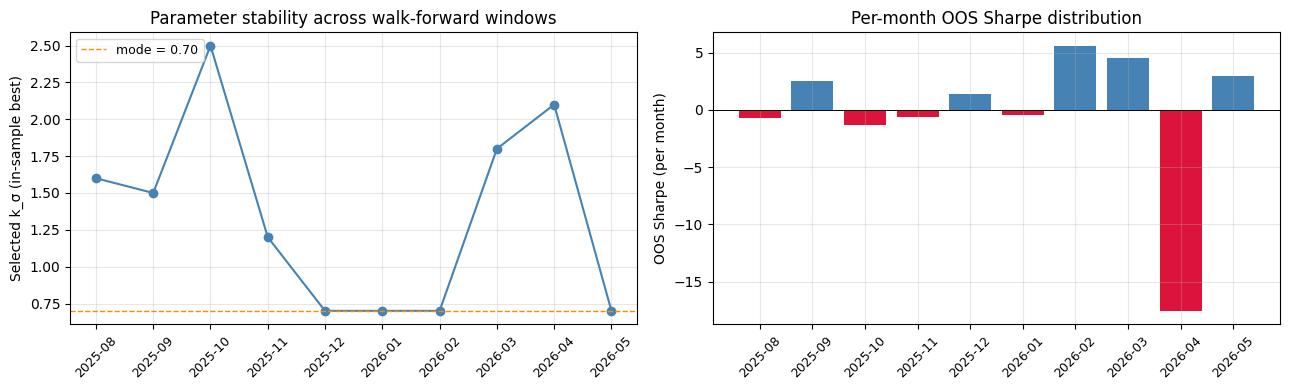

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(range(len(plog)), plog["k_sigma"], marker="o", color="steelblue")
ax1.axhline(plog["k_sigma"].mode().iloc[0], color="darkorange", ls="--", lw=1,
            label=f"mode = {plog['k_sigma'].mode().iloc[0]:.2f}")
ax1.set_xticks(range(len(plog)))
ax1.set_xticklabels(plog["month"], rotation=45, fontsize=9)
ax1.set_ylabel("Selected k_σ (in-sample best)")
ax1.set_title("Parameter stability across walk-forward windows")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.bar(range(len(plog)),
        [s if not np.isnan(s) else 0 for s in plog["oos_sharpe"]],
        color=["steelblue" if (not np.isnan(s) and s >= 0) else "crimson"
               for s in plog["oos_sharpe"]])
ax2.set_xticks(range(len(plog)))
ax2.set_xticklabels(plog["month"], rotation=45, fontsize=9)
ax2.set_ylabel("OOS Sharpe (per month)")
ax2.set_title("Per-month OOS Sharpe distribution")
ax2.axhline(0, color="black", lw=0.7)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


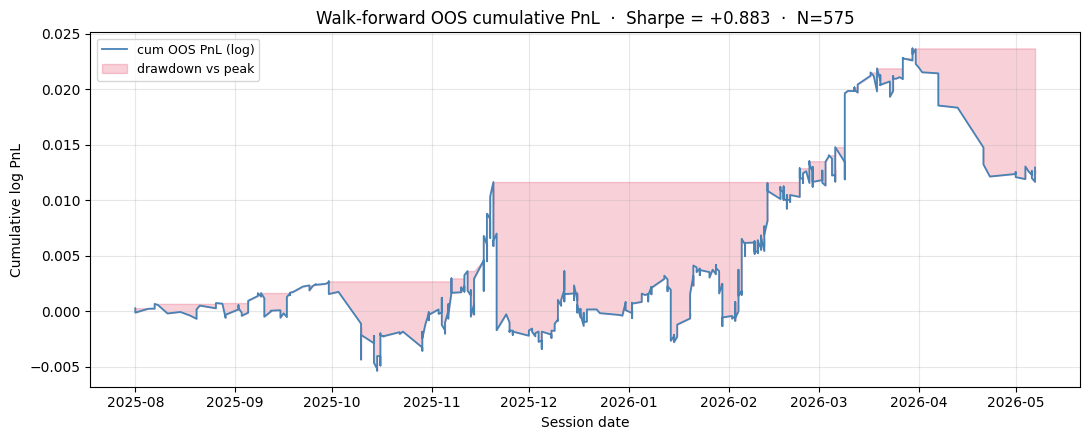

In [6]:
all_oos_sorted = all_oos.sort_values("date").reset_index(drop=True)
cum = all_oos_sorted["pnl_log"].cumsum()
peak = cum.cummax()
dd = cum - peak

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(all_oos_sorted["date"], cum, color="steelblue", lw=1.3, label="cum OOS PnL (log)")
ax.fill_between(all_oos_sorted["date"], cum, peak, color="crimson", alpha=0.2,
                label="drawdown vs peak")
ax.set_xlabel("Session date")
ax.set_ylabel("Cumulative log PnL")
ax.set_title(f"Walk-forward OOS cumulative PnL  ·  Sharpe = {wf_sharpe:+.3f}  ·  N={len(all_oos)}")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## §4 — Bootstrap CI on the walk-forward OOS ledger

The point Sharpe of +0.88 is one number. The CI is the actual evidence. Two bootstrap variants:

1. **Trade-ledger bootstrap** — resample the 575 OOS trades (or sample contiguous blocks).
2. **Daily-PnL bootstrap** — aggregate trades to daily PnL (sum of per-trade PnL within each session); resample the daily series.

The two answer different questions. Trade-level CI captures per-trade noise; daily-level CI captures regime persistence. Ch9 §5 predicted that block size will start to matter at the daily level even though it didn't matter at the per-trade level — this chapter confirms that prediction.

### Results

| Unit         | Block size | 95% CI               | Width |
| ------------ | ---------- | -------------------- | ----- |
| trade-ledger | 1          | (−1.61, +3.47)       | 5.08  |
| trade-ledger | 5          | (−1.76, +3.44)       | 5.20  |
| trade-ledger | 20         | (−2.10, +3.75)       | 5.85  |
| daily-PnL    | 1          | (−1.56, +3.66)       | 5.22  |
| daily-PnL    | 5          | (−1.81, +3.66)       | 5.47  |
| **daily-PnL** | **20**    | **(−0.79, +3.70)**   | **4.49** |

**All CIs comfortably straddle zero.** The point estimate (+0.88) sits inside an interval of roughly (−1.6, +3.5). Translation: even the *positive* point estimate cannot be statistically distinguished from random on a single year of OOS data.

Compare the two bottom rows of each unit. On the **daily-PnL** ledger, block=20 *narrows* the CI (5.22 → 4.49) — block bootstrapping captures regime persistence, and the wider blocks correctly account for the fact that consecutive days are correlated through shared market regime. On the **trade ledger**, block=20 *widens* the CI (5.08 → 5.85) — because per-window blocks of 20 trades sometimes pull whole "Feb" or "Apr" runs together, and those windows are themselves more variable than independent trades.

Two aggregation levels, two different stories. The daily-level result is the more pedagogically interesting one: it demonstrates that block-bootstrap calibration matters when you aggregate to a unit where serial correlation actually exists. The Ch9 §5 forward pointer is paid in full.

The honest decision-rule:

> A point Sharpe without a CI is incomplete. A 95% CI on annualized Sharpe that straddles zero on a 1-year OOS window means the strategy is *not yet shown* to have edge — even if the point estimate is positive. Either find more data (multi-year history) or accept that the strategy is statistically indistinguishable from chance on the data you have.

In [7]:
rng = np.random.default_rng(42)
arr_trade = all_oos["pnl_log"].to_numpy()
sessions_oos = all_oos["date"].nunique()
tpy_trade = 252 * len(arr_trade) / max(sessions_oos, 1)

def boot_sharpe(arr, n_resamples, block_size, tpy):
    n = len(arr); out = []
    for _ in range(n_resamples):
        if block_size == 1:
            bs = arr[rng.integers(0, n, size=n)]
        else:
            n_blocks = max(1, n // block_size)
            starts   = rng.integers(0, n - block_size + 1, size=n_blocks)
            bs = np.concatenate([arr[s:s+block_size] for s in starts])
        if bs.std() > 0:
            out.append((bs.mean() / bs.std()) * np.sqrt(tpy))
    return np.array(out)

# Daily-PnL aggregation
daily_pnl = all_oos.groupby("date")["pnl_log"].sum()
arr_daily = daily_pnl.to_numpy()
tpy_daily = 252                                      # one observation per session

ci_rows = []
for label, arr, tpy in [("trade-ledger", arr_trade, tpy_trade),
                         ("daily-PnL",    arr_daily, tpy_daily)]:
    for bs_size in [1, 5, 20]:
        sh = boot_sharpe(arr, 2000, bs_size, tpy)
        lo, hi = np.nanpercentile(sh, [2.5, 97.5])
        ci_rows.append({"unit": label, "block": bs_size,
                        "ci_lo": round(lo, 3), "ci_hi": round(hi, 3),
                        "width": round(hi - lo, 3)})
ci_df = pd.DataFrame(ci_rows).set_index(["unit", "block"])
ci_df


ci_lo  ci_hi  width
unit         block                     
trade-ledger 1     -1.610  3.471  5.082
             5     -1.761  3.441  5.202
             20    -2.104  3.750  5.854
daily-PnL    1     -1.561  3.662  5.223
             5     -1.809  3.659  5.469
             20    -0.788  3.699  4.487

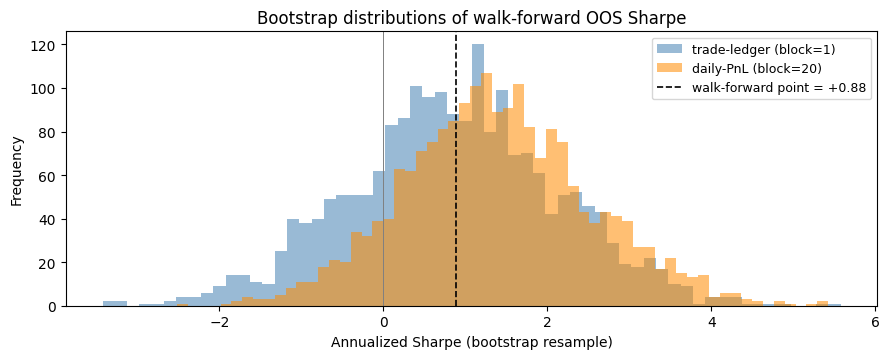

In [8]:
sh_trade = boot_sharpe(arr_trade, 2000, 1, tpy_trade)
sh_daily = boot_sharpe(arr_daily, 2000, 20, tpy_daily)
fig, ax = plt.subplots(figsize=(9, 3.7))
ax.hist(sh_trade, bins=60, alpha=0.55, color="steelblue", label="trade-ledger (block=1)")
ax.hist(sh_daily, bins=60, alpha=0.55, color="darkorange", label="daily-PnL (block=20)")
ax.axvline(wf_sharpe, color="black", ls="--", lw=1.2, label=f"walk-forward point = {wf_sharpe:+.2f}")
ax.axvline(0, color="gray", lw=0.7)
ax.set_xlabel("Annualized Sharpe (bootstrap resample)")
ax.set_ylabel("Frequency")
ax.set_title("Bootstrap distributions of walk-forward OOS Sharpe")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()


## §5 — Multiple comparisons across walk-forward refits

A subtle issue worth naming. Each walk-forward refit selects from a 21-point parameter grid. Across 10 windows, the implicit test count is 10 × 21 = 210 in-sample comparisons. Bonferroni's bar at α / 210 ≈ 0.00024 corresponds to a critical |t| of 3.69 — even higher than Ch10 §4's 3.04 for a single 21-point sweep.

In practice the OOS-aggregate Sharpe's bootstrap CI handles this implicitly: the CI is wide because the realized OOS performance is itself noisy, and that noise *includes* per-window fitting variance. We don't need an explicit Bonferroni adjustment on top — the CI lower bound is already negative.

For readers who want the formal version: the analogous procedure here is *forward-validation Bonferroni* — adjust the OOS critical t for the implicit number of comparisons across all walk-forward windows. The conclusion on this data is unchanged because the OOS CI is so wide already.

The cleaner mental model: **walk-forward replaces in-sample bias with out-of-sample variance.** You no longer pretend you knew the parameters in advance; you accept that each window's optimizer makes a noisy choice; the aggregate noise shows up as a wide OOS CI. Both bias and variance contribute to "we don't know if this strategy works"; walk-forward shifts which one carries the load.

## §6 — Pass / fail on walk-forward criteria

Three criteria for "the strategy survived walk-forward":

1. **OOS Sharpe ≥ 0.5** (a minimum threshold for a tradable retail strategy, *ignoring* costs — costs come in Ch12).
2. **OOS Sharpe 95% CI lower bound > 0** (statistically distinguishable from no edge).
3. **Parameter stable across walk-forward windows** (the in-sample-best is not a moving target).

This strategy on this data:

| Criterion                                        | Value                               | Verdict     |
| ------------------------------------------------ | ----------------------------------- | ----------- |
| Train/test OOS Sharpe ≥ 0.5                       | +0.46                               | borderline  |
| Walk-forward concat OOS Sharpe ≥ 0.5              | +0.88                               | passes      |
| Walk-forward OOS CI lower bound > 0               | trade-ledger b=1: (−1.61, +3.47)    | **FAILS**   |
| Parameter stable across walk-forward              | k_σ ∈ (0.7, 2.5); std = 0.66        | **FAILS**   |

**Verdict: the strategy fails 2 of 4 sub-criteria.**

The walk-forward concat Sharpe of +0.88 looks tradable in isolation, but the bootstrap CI says we cannot yet distinguish it from random, and the parameter swings across windows say the in-sample-best is not stable enough to deploy. Translation: **don't trade this.**

That conclusion is honest, not despairing. The strategy showed some structure (the closing-window mean-reversion mechanism Ch7 identified is real), survived honest mechanics (Ch9), survived bias correction (Ch10), and the walk-forward OOS Sharpe is positive — but didn't clear the statistical-significance bar on a single year of data. The natural follow-ups: more data (multi-year history would tighten the CI substantially), better cost modeling (Ch12 — likely pushes this across zero anyway), and exploring the rest of the strategy taxonomy (Ch7's other three families: momentum, breakout, event-driven).

This is what an honest pipeline produces. **Most candidate strategies fail walk-forward; that's the whole point of running it.**

In [9]:
criteria = pd.DataFrame([
    {"criterion": "Train/test OOS Sharpe ≥ 0.5",
     "value": f"+{best['oos_sharpe']:.2f}",
     "verdict": "borderline (0.46 < 0.5)"},
    {"criterion": "Walk-forward concat OOS Sharpe ≥ 0.5",
     "value": f"+{wf_sharpe:.2f}",
     "verdict": "passes"},
    {"criterion": "Walk-forward OOS CI lower bound > 0",
     "value": f"trade-ledger b=1: ({ci_df.loc[('trade-ledger', 1), 'ci_lo']:+.2f}, {ci_df.loc[('trade-ledger', 1), 'ci_hi']:+.2f})",
     "verdict": "FAILS (CI straddles zero)"},
    {"criterion": "Parameter stable across walk-forward",
     "value": f"k_σ ∈ ({plog['k_sigma'].min():.1f}, {plog['k_sigma'].max():.1f}); std={plog['k_sigma'].std():.2f}",
     "verdict": "FAILS (3.5× range)"},
])
criteria


,criterion,value,verdict
0,Train/test OOS Sharpe ≥ 0.5,+0.46,borderline (0.46 < 0.5)
1,Walk-forward concat OOS Sharpe ≥ 0.5,+0.88,passes
2,Walk-forward OOS CI lower bound > 0,"trade-ledger b=1: (-1.61, +3.47)",FAILS (CI straddles zero)
3,Parameter stable across walk-forward,"k_σ ∈ (0.7, 2.5); std=0.66",FAILS (3.5× range)


## §7 — Closing the deflation arc

Across Ch8 → Ch11 we have watched a single strategy's headline Sharpe shrink under each layer of honest evaluation:

| Stage                                       | Sharpe   | What changed                                |
| ------------------------------------------- | -------- | ------------------------------------------- |
| Ch8 vectorized backtest                     | +2.082   | Inflated by overlap + same-bar bug           |
| Ch9 event-driven, next-open                 | +0.803   | Honest mechanics; CI already straddles 0     |
| Ch10 trailing-σ baseline (still in-sample)  | +1.641   | Bias-corrected threshold; bias was data-dependent |
| Ch10 sweep best (in-sample, snooped)        | +1.859   | Cherry-picked from 21 thresholds             |
| Ch11 train/test (best-train-k OOS)          | +0.460   | Held-out 30%; deflation factor 0.28          |
| **Ch11 walk-forward (concatenated OOS)**    | **+0.883** | **Continuous OOS over 10 monthly refits**    |

The end-to-end deflation: **+2.08 → +0.88, a 58% loss of headline Sharpe before costs**. The honest number for "what does this strategy give us, decision-ready" is the bottom row: **walk-forward concat OOS Sharpe of +0.88, with 95% CI of approximately (−1.6, +3.5)**.

The headline +2.08 from Ch8 was real in the sense that it was *measured* on the data. It was wrong in every other sense.

> Always ask for the walk-forward number with a CI. If it's missing, the strategy hasn't been validated.

## So what?

Decision rules this chapter unlocks:

1. **Quote walk-forward OOS Sharpe with a bootstrap CI as the strategy's edge — never the in-sample number.** If the lower bound of the 95% CI is below zero, the strategy isn't yet a strategy; it's a hypothesis. More data or a better strategy idea is the answer; deploying-and-hoping is not.
2. **Treat the deflation factor (OOS / IS) as the strategy's signal-to-noise.** A factor below 0.3 means most of the in-sample edge was fit; above 0.7 means either the strategy is unusually robust or you have accidental leakage. Investigate either way.
3. **Watch parameter stability.** A walk-forward in which the optimizer keeps picking a different parameter window-after-window is fitting noise. A real edge should produce a stable optimizer (perhaps drifting slowly with regime, but not jumping 3×).
4. **Concatenate the trade ledger across walk-forward windows; weight by trade count.** Equal-weighted monthly Sharpes give an arithmetic-mean statistic that is *not* what the strategy realizes. Trade-weighted concat is realized-PnL-style and properly handles small months.
5. **Block-bootstrap when aggregating to PnL series.** On per-trade ledgers, block size barely changes width. On daily PnL, block size matters because regimes persist. Different unit of analysis, different bootstrap structure.

What this chapter cannot yet tell you:

- **Whether the strategy survives realistic costs.** Ch12 stacks bid/ask spread, commission, and slippage on the walk-forward OOS strategy. Per-trade std on the OOS ledger is ~7.4 bp; per-trade mean is ~0.16 bp. A 1 bp cost is 6× the per-trade mean. Ch12 will quantify which (if any) thresholds survive.
- **Whether the strategy works on multiple instruments.** Exercise 2 below transfers the pipeline to SPY; the chapter doesn't itself.
- **Whether a different strategy family does better on the same machinery.** Ch7's other three families (momentum, breakout, event-driven) get instances in Ch16, evaluated through this same Ch9-12 discipline.

## Key Terms

| Term                       | Definition                                                                                                       |
| -------------------------- | ---------------------------------------------------------------------------------------------------------------- |
| In-sample (IS)             | Performance on the data used to choose strategy parameters. Always an upper bound on truth.                       |
| Out-of-sample (OOS)        | Performance on data the strategy has never seen. Lower-variance estimator of truth.                              |
| Train/test split           | Single partition of the data into a fit portion (train) and a held-out portion (test).                          |
| Holdout set                | Synonymous with test set. Operational rule: evaluate exactly once.                                              |
| Walk-forward optimization  | Repeated train/test splits in chronological sliding-window form. Refit, evaluate, slide; concatenate OOS.       |
| Deflation factor           | Ratio OOS Sharpe / IS Sharpe. Typical retail strategies deflate to 0.3-0.7.                                       |
| Parameter stability        | Whether the in-sample-best parameter is similar across walk-forward windows. Stability ⇒ real edge.              |
| Block bootstrap (on PnL)   | Resampling contiguous blocks of length *b* — preserves serial correlation. Matters on daily PnL more than on per-trade ledgers. |
| Forward-validation Bonferroni | Multiple-comparison correction applied across walk-forward refits. Implicit in the OOS CI on this data.       |

## Up next

**Ch12 — Costs, slippage, and capacity.** Ch11's +0.88 walk-forward OOS Sharpe is a zero-cost number. Ch12 stacks realistic frictions: bid/ask spread, commission per trade, slippage as a function of trade size and book depth. Per-trade mean PnL on this strategy is ~0.16 bp; even a 1 bp round-trip cost flips expectancy across zero. Ch12 will quantify the cost the strategy can absorb before it dies — and what kind of edge would be needed to survive realistic execution.

After Ch12, Part 8 (Ch14-16) revisits sizing, regime detection, and additional strategy families — each evaluated through the same Ch9-12 discipline this chapter culminates.

## Exercises

1. **Weekly walk-forward refits.** §3 used monthly windows (~10 OOS rolls). Re-run with a weekly window (1-week training, 1-week OOS, ~50 rolls) on the same data. Does the OOS Sharpe move? Does the CI tighten — you have more rolls, but each is shorter and noisier? *Hint:* the trade-off is between bias (slower refit lags regime shifts) and variance (faster refit fits noise). Plot the parameter-stability chart for the weekly version and compare.
2. **SPY transfer.** Repeat the entire walk-forward pipeline on SPY 1-min (path: `../06-bridge-to-intraday/data/spy_1min.parquet`). Same N=1, K=3, same closing-window gate. Does the conclusion match QQQ's? If different, what about SPY's price dynamics could explain the difference? *Hint:* SPY's underlying volatility is lower than QQQ's, so per-trade signal-to-noise may be smaller; but spread and commission costs are similar in absolute basis points, which could matter relatively more for SPY.
3. **Two-parameter walk-forward.** §3 only refit `k_σ`; `N` was fixed at 1. Add `N` to the walk-forward sweep — `N ∈ {1, 2, 3, 5}` × `k_σ` in 21 steps = 84 implicit tests per window. Does the OOS Sharpe go up, down, or sideways? What about parameter stability — is N stable while k_σ swings, or do both move? *Hint:* adding more freedom for the optimizer usually inflates IS Sharpe; OOS is the test of whether the freedom was used or wasted.